### Read-in downloaded data

In [1]:
import pandas as pd
import pandas_profiling
import numpy as np

In [2]:
data = pd.read_csv("csv/2021-10-28.csv", index_col = False)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5633602 entries, 0 to 5633601
Data columns (total 21 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   viewer_id                      object 
 1   broadcaster_id                 object 
 2   viewer_age                     float64
 3   viewer_gender                  object 
 4   viewer_longitude               float64
 5   viewer_latitude                float64
 6   viewer_lang                    object 
 7   viewer_country                 object 
 8   broadcaster_age                float64
 9   broadcaster_gender             object 
 10  broadcaster_longitude          float64
 11  broadcaster_latitude           float64
 12  broadcaster_lang               object 
 13  broadcaster_country            object 
 14  duration                       int64  
 15  viewer_network                 object 
 16  broadcaster_network            object 
 17  count                          int64  
 18  br

In [4]:
data.head()

,viewer_id,broadcaster_id,viewer_age,viewer_gender,viewer_longitude,viewer_latitude,viewer_lang,viewer_country,broadcaster_age,broadcaster_gender,...,broadcaster_latitude,broadcaster_lang,broadcaster_country,duration,viewer_network,broadcaster_network,count,broadcast_active_viewer_count,viewer_lat_long_cluster,rank
0,99 a1 08 11 6c 34 6b 98 33 1e 29 d9 99 09 4d 8d,81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79,33.0,female,-86.6716,37.1323,en,US,37.0,female,...,34.5363,en,US,73,meetme,meetme,1,2021-10-27:26,0,1
1,e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67,52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f,28.0,male,-86.6716,36.1323,en,US,29.0,female,...,35.0939,en,US,6821,meetme,meetme,16,"2021-10-22:3,2021-10-22:2,2021-10-22:2,2021-10...",0,1
2,33 47 6e 09 04 7a 6f 93 a6 81 90 09 27 9d 87 b9,b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23,27.0,male,-86.6716,36.1323,en,US,28.0,female,...,40.7521,en,US,65,meetme,meetme,1,2021-10-28:6,0,1
3,5f 4e 1a e0 28 93 1c 98 cd 35 85 5c 39 b6 ac ec,b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 af e5,47.0,male,-85.6716,37.1323,en,US,25.0,male,...,38.7856,en,US,72,meetme,meetme,4,"2021-10-28:2,2021-10-28:2",0,1
4,e1 91 07 68 40 d1 59 e0 49 e0 01 37 e1 be cc c4,18 16 f8 f2 e7 3e 76 ac 24 01 c8 86 75 71 b6 ec,32.0,male,-85.6716,37.1323,en,US,26.0,male,...,34.9000,en,US,64,meetme,pof,4,"2021-10-24:14,2021-10-24:16",0,1


### TFIDF

Inverse frequency factors into the equation because interactions with less popular broadcasters provide more information about the viewers than interactions with popular broadcasters.

```
tf, the term frequency, TF for a word in a "document"
, word_day_station AS (
  #how many times a word is mentioned in each "document"
  SELECT viewer_id, SUM(count) counts, broadcaster_id
  FROM data
  GROUP BY 1, 3
)
, day_station AS (
  #total # of words in each "document" 
  SELECT SUM(count) counts, broadcaster_id
  FROM data
  GROUP BY 2
)
, tf AS (
  #TF for a word in a "document"
  SELECT viewer_id, broadcaster_id, a.counts/b.counts tf
  FROM word_day_station a
  JOIN day_station b
  USING(broadcaster_id)
)
```

In [6]:
df = data.copy()

In [7]:
df_tf = df.groupby(['broadcaster_id'])['count'].sum().to_frame('tf').reset_index()

In [8]:
tf_mapping = df_tf.set_index('broadcaster_id')['tf'].to_dict()

In [9]:
df['tf'] = df['count']/df['broadcaster_id'].map(tf_mapping)

In [10]:
df[['viewer_id', 'broadcaster_id', 'count','tf']].head()

,viewer_id,broadcaster_id,count,tf
0,99 a1 08 11 6c 34 6b 98 33 1e 29 d9 99 09 4d 8d,81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79,1,0.000208
1,e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67,52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f,16,0.003699
2,33 47 6e 09 04 7a 6f 93 a6 81 90 09 27 9d 87 b9,b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23,1,0.004630
3,5f 4e 1a e0 28 93 1c 98 cd 35 85 5c 39 b6 ac ec,b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 af e5,4,0.000961
4,e1 91 07 68 40 d1 59 e0 49 e0 01 37 e1 be cc c4,18 16 f8 f2 e7 3e 76 ac 24 01 c8 86 75 71 b6 ec,4,0.000254


```
idf, the inverse document frequency,
, word_in_docs AS (
  # how many "documents" have a word
  SELECT viewer_id, COUNT(DISTINCT broadcaster_id) indocs
  FROM word_day_station
  GROUP BY 1
)
, total_docs AS (
  # total # of docs
  SELECT COUNT(DISTINCT DISTINCT broadcaster_id) total_docs
  FROM data
)
, idf AS (
  # IDF for a word
  SELECT viewer_id, LOG(total_docs.total_docs/indocs) idf
  FROM word_in_docs
  CROSS JOIN total_docs
)
```

In [11]:
N = df['viewer_id'].nunique()

In [12]:
N

773328

In [13]:
df_idf = df.groupby(['viewer_id'])['broadcaster_id'].nunique().to_frame('df').reset_index()

In [14]:
from math import log10
df_idf['idf'] = df_idf['df'].apply(lambda x: round(1 + log10(N / (1 + x)), 3))

```
tfidf

    SELECT viewer_id, broadcaster, tf.tf * idf.idf tfidf
    FROM tf
    JOIN idf
    USING(viewer_id)
```

In [15]:
idf_mapping = df_idf.set_index('viewer_id')['idf'].to_dict()

In [16]:
df['idf'] = df['viewer_id'].map(idf_mapping)

In [17]:
df['tfidf'] = df['tf'] * df['idf']

In [18]:
df[['viewer_id', 'broadcaster_id', 'count','tf', 'idf', 'tfidf']].head()

,viewer_id,broadcaster_id,count,tf,idf,tfidf
0,99 a1 08 11 6c 34 6b 98 33 1e 29 d9 99 09 4d 8d,81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79,1,0.000208,6.043,0.001259
1,e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67,52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f,16,0.003699,5.309,0.019636
2,33 47 6e 09 04 7a 6f 93 a6 81 90 09 27 9d 87 b9,b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23,1,0.004630,5.411,0.025051
3,5f 4e 1a e0 28 93 1c 98 cd 35 85 5c 39 b6 ac ec,b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 af e5,4,0.000961,4.969,0.004777
4,e1 91 07 68 40 d1 59 e0 49 e0 01 37 e1 be cc c4,18 16 f8 f2 e7 3e 76 ac 24 01 c8 86 75 71 b6 ec,4,0.000254,5.441,0.001384


In [19]:
df['tfidf'].describe()

count    5.633602e+06
mean     1.110505e-01
std      4.559589e-01
min      7.991466e-06
25%      3.141588e-03
50%      1.113770e-02
75%      4.458156e-02
max      6.587000e+00
Name: tfidf, dtype: float64

### weight decays for broadcast_active_viewer_count

In [20]:
df['broadcast_active_viewer_count']

0                                              2021-10-27:26
1          2021-10-22:3,2021-10-22:2,2021-10-22:2,2021-10...
2                                               2021-10-28:6
3                                  2021-10-28:2,2021-10-28:2
4                                2021-10-24:14,2021-10-24:16
                                 ...                        
5633597                                         2021-10-25:5
5633598                                         2021-10-22:7
5633599                                        2021-10-25:13
5633600                                        2021-10-26:11
5633601    2021-10-24:9,2021-10-24:22,2021-10-24:13,2021-...
Name: broadcast_active_viewer_count, Length: 5633602, dtype: object

In [21]:
from datetime import datetime, timedelta

In [22]:
date_format = '%Y-%m-%d'
date_format_full = '%Y-%m-%d %H:%M:%S'

def dt_to_str(date, dateformat):
    """Convert Python datetime.datetime object to string YYYY-MM-DD."""
    return date.strftime(dateformat)

def dt_from_str(date, dateformat):
    """Convert string YYYY-MM-DD to Python datetime.datetime object."""
    return datetime.strptime(date, dateformat)

In [23]:
dt_to_str(datetime.now(), date_format)

'2021-11-03'

In [24]:
end_dt = dt_from_str('2021-10-29', date_format)

In [30]:
def add_broadcast_active_viewer_columns(df):
    weights = [1/i for i in range(1, 9)]
    res = []
    for k, v in enumerate(df['broadcast_active_viewer_count']):
        if len(v) > 0:
            sourcemap = {}
            for item in v.split(","):
                if ":" in item:
                    dt, cnt = item.split(":")
                    cnt = int(cnt)
                    visit_dt = dt_from_str(dt, date_format)
                    delta = end_dt - visit_dt
                    if dt not in sourcemap:
                        sourcemap[dt] = weights[delta.days-1] * cnt
                    else:
                        sourcemap[dt] += weights[delta.days-1] * cnt
            res.append(sum(sourcemap.values()))
        else:
            res.append(0)
    return res

In [34]:
def add_decay_broadcast_active_viewer(v):
    weights = [1/i for i in range(1, 9)]
    res = 0
    if isinstance(v, str) and len(v) > 0:
        sourcemap = {}
        for item in v.split(","):
            if ":" in item:
                dt, cnt = item.split(":")
                cnt = int(cnt)
                visit_dt = dt_from_str(dt, date_format)
                delta = end_dt - visit_dt
                if dt not in sourcemap:
                    sourcemap[dt] = weights[delta.days-1] * cnt
                else:
                    sourcemap[dt] += weights[delta.days-1] * cnt
        res = sum(sourcemap.values())
    return res

In [36]:
df['decay_broadcast_active_viewer_count'] = df['broadcast_active_viewer_count'].apply(lambda x: add_decay_broadcast_active_viewer(x))

In [37]:
df[['count', 'broadcast_active_viewer_count', 'decay_broadcast_active_viewer_count']].head(10)

,count,broadcast_active_viewer_count,decay_broadcast_active_viewer_count
0,1,2021-10-27:26,13.000000
1,16,"2021-10-22:3,2021-10-22:2,2021-10-22:2,2021-10...",15.800000
2,1,2021-10-28:6,6.000000
3,4,"2021-10-28:2,2021-10-28:2",4.000000
4,4,"2021-10-24:14,2021-10-24:16",6.000000
5,1,2021-10-26:9,3.000000
6,1,2021-10-27:21,10.500000
7,3,"2021-10-23:4,2021-10-27:4,2021-10-22:7",3.666667
8,1,2021-10-28:1,1.000000
9,4,NaN,0.000000


In [38]:
df['decay_broadcast_active_viewer_count'].describe()

count    5.633602e+06
mean     1.061002e+01
std      8.175454e+01
min      0.000000e+00
25%      6.666667e-01
50%      2.000000e+00
75%      6.166667e+00
max      5.064686e+04
Name: decay_broadcast_active_viewer_count, dtype: float64

In [42]:
df = df[['viewer_id', 'broadcaster_id', 'viewer_age', 'viewer_gender',
       'viewer_longitude', 'viewer_latitude', 'viewer_lang', 'viewer_country',
       'broadcaster_age', 'broadcaster_gender', 'broadcaster_longitude',
       'broadcaster_latitude', 'broadcaster_lang', 'broadcaster_country',
       'duration', 'viewer_network', 'broadcaster_network', 'count',
       'viewer_lat_long_cluster', 'tfidf', 'decay_broadcast_active_viewer_count']]

In [43]:
df.to_csv("csv/2021-10-28-cleaned.csv", index=False)

### Read-in cleaned data

In [1]:
import os
import logging
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs

In [2]:
def get_broadcaster_data_set(train_ds):
    broadcasters = train_ds.cache().map(lambda x: x["broadcaster"], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    broadcasters_ds = tf.data.Dataset.from_tensor_slices(
        np.unique(list(broadcasters.as_numpy_iterator())))
    return broadcasters_ds

def get_list(training_data, key):
    return training_data.batch(1_000_000).map(lambda x: x[key], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)


def get_unique_list(data):
    return np.unique(np.concatenate(list(data)))


def load_data_file_cold(file, stats):
    print('loading file:' + file)
    training_df = pd.read_csv(
        file,
        skiprows=[0],
        names=["viewer",
               "broadcaster",
               "viewer_age",
               "viewer_gender",
               "viewer_longitude",
               "viewer_latitude",
               "viewer_lang",
               "viewer_country",
               "broadcaster_age",
               "broadcaster_gender",
               "broadcaster_longitude",
               "broadcaster_latitude",
               "broadcaster_lang",
               "broadcaster_country",
               "duration", 
               "viewer_network", 
               "broadcaster_network", 
               "count",
               "viewer_lat_long_cluster", 
               "tfidf", 
               "decay_broadcast_active_viewer_count"
              ], 
        dtype={
            'viewer': np.unicode,
            'broadcaster': np.unicode,
            'viewer_age': np.single,
            'viewer_gender': np.unicode,
            'viewer_longitude': np.single,
            'viewer_latitude': np.single,
            'viewer_lang': np.unicode,
            'viewer_country': np.unicode,
            'broadcaster_age': np.single,
            'broadcaster_longitude': np.single,
            'broadcaster_latitude': np.single,
            'broadcaster_lang': np.unicode,
            'broadcaster_country': np.unicode,
            'viewer_network': np.unicode,
            'broadcaster_network': np.unicode,
            'count': np.unicode,
            'viewer_lat_long_cluster':np.unicode,
            'tfidf':np.single,
            'decay_broadcast_active_viewer_count': np.single
        })

    values = {
        'viewer': 'unknown',
        'broadcaster': 'unknown',
        'viewer_age': 30,
        'viewer_gender': 'unknown',
        'viewer_longitude': 0,
        'viewer_latitude': 0,
        'viewer_lang': 'unknown',
        'viewer_country': 'unknown',
        'broadcaster_age': 30,
        'broadcaster_longitude': 0,
        'broadcaster_latitude': 0,
        'broadcaster_lang': 'unknown',
        'broadcaster_country': 'unknown',
        'duration': 0,
        'viewer_network': 'unknown',
        'broadcaster_network': 'unknown',
        'viewer_lat_long_cluster': '0',
        'count': '1',
        'viewer_lat_long_cluster': '0',
        'tfidf': 0,
        'decay_broadcast_active_viewer_count': 1
    }
    training_df.fillna(value=values, inplace=True)
    print(training_df.head(10))
    print(training_df.iloc[-10:])
    # stats.send_stats('data-size', len(training_df.index))
    samples = training_df.sample(frac=.1)
    return samples


def load_training_data_cold(file, stats):
    ratings_df = load_data_file_cold(file, stats)
    print('creating data set')
    training_ds = (
        tf.data.Dataset.from_tensor_slices(
            ({
                "viewer": tf.cast(
                    ratings_df['viewer'].values,
                    tf.string),
                "viewer_gender": tf.cast(
                    ratings_df['viewer_gender'].values,
                    tf.string),
                "viewer_lang": tf.cast(
                    ratings_df['viewer_lang'].values,
                    tf.string),
                "viewer_country": tf.cast(
                    ratings_df['viewer_country'].values,
                    tf.string),
                "viewer_age": tf.cast(
                    ratings_df['viewer_age'].values,
                    tf.int32),
                "viewer_longitude": tf.cast(
                    ratings_df['viewer_longitude'].values,
                    tf.float16),
                "viewer_latitude": tf.cast(
                    ratings_df['viewer_latitude'].values,
                    tf.float16),
                "broadcaster": tf.cast(
                    ratings_df['broadcaster'].values,
                    tf.string),
                "viewer_network": tf.cast(
                    ratings_df['viewer_network'].values,
                    tf.string),
                "broadcaster_network": tf.cast(
                    ratings_df['broadcaster_network'].values,
                    tf.string),
                "viewer_lat_long_cluster": tf.cast(
                    ratings_df['viewer_lat_long_cluster'].values,
                    tf.string),
                "tfidf": tf.cast(
                    ratings_df['tfidf'].values,
                    tf.float16),
                "decay_broadcast_active_viewer_count": tf.cast(
                    ratings_df['decay_broadcast_active_viewer_count'].values,
                    tf.float16),
            })))

    return training_ds

            
def prepare_training_data_cold(train_ds):
    print('prepare_training_data')
    training_ds = train_ds.cache().map(lambda x: {
        "broadcaster": x["broadcaster"],
        "viewer": x["viewer"],
        "viewer_gender": x["viewer_gender"],
        "viewer_lang": x["viewer_lang"],
        "viewer_country": x["viewer_country"],
        "viewer_age": x["viewer_age"],
        "viewer_longitude": x["viewer_longitude"],
        "viewer_latitude": x["viewer_latitude"],
        "viewer_network": x["viewer_network"],
        "broadcaster_network": x["broadcaster_network"],
        "viewer_lat_long_cluster": x["viewer_lat_long_cluster"],
        "tfidf": x["tfidf"],
        "decay_broadcast_active_viewer_count": x["decay_broadcast_active_viewer_count"]
    }, num_parallel_calls=tf.data.AUTOTUNE,
       deterministic=False)

    print('done prepare_training_data')
    return training_ds


def current_milli_time():
    return round(time.time() * 1000)

### Read-in data

In [3]:
print("training_process")
start_time = current_milli_time()
broadcaster_embedding_dimension = 32
viewer_embedding_dimension = 32

batch_size = 1638
learning_rate = 0.05
epochs = 10
top_k = 199

training_process


In [4]:
!ls csv

0e9cd673-8e06-4810-b370-8b9930ee312a.csv
2021-09-22.csv
2021-09-23.csv
2021-10-01.csv
2021-10-05.csv
2021-10-07.csv
2021-10-28-cleaned.csv
2021-10-28.csv
50c39121-3de2-4b6b-b134-bb51732c1d6f.csv
a3d86f3b-eb45-4641-b05d-30dff7423e6b.csv
res.csv
viewer_lat_long_centroids.csv


In [5]:
training_dataset = load_training_data_cold("csv/2021-10-28-cleaned.csv", "")
train = prepare_training_data_cold(training_dataset)

loading file:csv/2021-10-28-cleaned.csv
                                            viewer  \
0  99 a1 08 11 6c 34 6b 98 33 1e 29 d9 99 09 4d 8d   
1  e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67   
2  33 47 6e 09 04 7a 6f 93 a6 81 90 09 27 9d 87 b9   
3  5f 4e 1a e0 28 93 1c 98 cd 35 85 5c 39 b6 ac ec   
4  e1 91 07 68 40 d1 59 e0 49 e0 01 37 e1 be cc c4   
5  e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67   
6  e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67   
7  e5 10 06 42 cb 35 21 40 de 7b 8b ef 0c 9b 7f bc   
8  86 ea d8 9a f7 e1 98 45 23 1b ab 90 d4 71 c8 00   
9  83 88 d9 2a 38 0d cf ac a7 96 11 48 68 4c b0 8f   

                                       broadcaster  viewer_age viewer_gender  \
0  81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79        33.0        female   
1  52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f        28.0          male   
2  b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23        27.0          male   
3  b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 

creating data set


2021-11-04 14:47:10.163770: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


prepare_training_data
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
done prepare_training_data


In [6]:
broadcasters_data_set = get_broadcaster_data_set(training_dataset)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2021-11-04 14:47:10.838198: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)


In [7]:
print("get lists")

user_genders = get_list(train, "viewer_gender")
user_langs = get_list(train, "viewer_lang")
user_countries = get_list(train, "viewer_country")
user_networks = get_list(train, "viewer_network")
user_clusters = get_list(train, "viewer_lat_long_cluster")

viewer_age = get_list(train, "viewer_age")
viewer_longitude = get_list(train, "viewer_longitude")
viewer_latitude = get_list(train, "viewer_latitude")

broadcaster_ids = get_list(train, "broadcaster")

data_set_size = len(broadcaster_ids)

get lists
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity

In [8]:
print("get_unique_list")
unique_broadcasters = get_unique_list(broadcaster_ids)
unique_user_genders = get_unique_list(user_genders)
unique_user_langs = get_unique_list(user_langs)
unique_user_countries = get_unique_list(user_countries)
unique_user_networks = get_unique_list(user_networks)
unique_user_clusters = get_unique_list(user_clusters)

get_unique_list


In [9]:
print("unique broadcasters: " + str(len(unique_broadcasters)))

unique broadcasters: 67787


In [10]:
tfidf = get_list(train, "tfidf")

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [11]:
max_tfidf = tfidf.reduce(tf.cast(0.0, tf.float16), tf.maximum).numpy().max()
tfidf_buckets = np.linspace(0, max_tfidf, num=10)
print(f"tfidf_buckets: {tfidf_buckets}")

tfidf_buckets: [0.         0.73177083 1.46354167 2.1953125  2.92708333 3.65885417
 4.390625   5.12239583 5.85416667 6.5859375 ]


In [12]:
decay_broadcast_active_viewer_count = get_list(train, "decay_broadcast_active_viewer_count")

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [13]:
max_decay_broadcast_active_viewer_count = decay_broadcast_active_viewer_count.reduce(tf.cast(0.0, tf.float16), tf.maximum).numpy().max()
decay_broadcast_active_viewer_count_buckets = np.linspace(0, max_decay_broadcast_active_viewer_count, num=10)
print(f"tfidf_buckets: {decay_broadcast_active_viewer_count_buckets}")

tfidf_buckets: [    0.  1208.  2416.  3624.  4832.  6040.  7248.  8456.  9664. 10872.]


### Baseline model with Viewer Lat and Log Cluster

In [14]:
class UserModel(tf.keras.Model) :

    def __init__(self, unique_genders, unique_langs, unique_countries, viewer_age, unique_networks, unique_clusters) :
        super().__init__()

        self.gender_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_genders, mask_token=None),
            tf.keras.layers.Embedding(len(unique_genders) + 1, 4),
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_langs, mask_token=None),
            tf.keras.layers.Embedding(len(unique_langs) + 1, 10),
        ])

        self.country_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_countries, mask_token=None),
            tf.keras.layers.Embedding(len(unique_countries) + 1, 10),
        ])

        self.network_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_networks, mask_token=None),
            tf.keras.layers.Embedding(len(unique_networks) + 1, 4),
        ])

        age_boundaries = np.array([18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")])
        self.viewer_age_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
            tf.keras.layers.Embedding(len(age_boundaries), 2)
        ])
        
        self.viewer_lat_long_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_clusters, mask_token=None),
            tf.keras.layers.Embedding(len(unique_clusters) + 1, 2),
        ])


    def call(self, inputs) :
        return tf.concat([
            self.gender_embedding(inputs["viewer_gender"]),
            self.lang_embedding(inputs["viewer_lang"]),
            self.country_embedding(inputs["viewer_country"]),
            self.network_embedding(inputs["viewer_network"]),
            self.viewer_age_embedding(inputs["viewer_age"]),
            self.viewer_lat_long_embedding(inputs["viewer_lat_long_cluster"]),
        ], axis = 1)

In [15]:
user_model = UserModel(unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters)

In [16]:
class BroadcasterModel(tf.keras.Model):

    def __init__(self, unique_broadcaster_titles, dims):
        super().__init__()

        self.broadcaster_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_broadcaster_titles, mask_token=None),
            tf.keras.layers.Embedding(len(unique_broadcaster_titles) + 1, dims)
        ])

    def call(self, broadcaster):
        return tf.concat([
            self.broadcaster_embedding(broadcaster),
        ], axis=1)

In [17]:
broadcaster_model = BroadcasterModel(
    unique_broadcasters,
    broadcaster_embedding_dimension)

In [18]:
metrics = tfrs.metrics.FactorizedTopK(
    candidates=broadcasters_data_set.batch(128).map(broadcaster_model)
)

task = tfrs.tasks.Retrieval(
    metrics=metrics
)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [19]:
from typing import Dict, Text

class TwoTowers(tf.keras.Model):

    def __init__(self, broadcaster_model, user_model, task):
        super().__init__()
        self.broadcaster_model: tf.keras.Model = broadcaster_model
        self.embedding_model = user_model
        self.task: tf.keras.layers.Layer = task

    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Set up a gradient tape to record gradients.
        with tf.GradientTape() as tape:

            # Loss computation.

            user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
            })
            positive_broadcaster_embeddings = self.broadcaster_model(
                features["broadcaster"])
            loss = self.task(user_embeddings, positive_broadcaster_embeddings)

            # Handle regularization losses as well.
            regularization_loss = sum(self.losses)

            total_loss = loss + regularization_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables))

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss

        return metrics

    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Loss computation.

        user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
        })
        positive_broadcaster_embeddings = self.broadcaster_model(
            features["broadcaster"])
        loss = self.task(user_embeddings, positive_broadcaster_embeddings)

        # Handle regularization losses as well.
        regularization_loss = sum(self.losses)

        total_loss = loss + regularization_loss

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        return metrics

In [20]:
model = TwoTowers(broadcaster_model, user_model, task)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(
        learning_rate=learning_rate))

In [22]:
tf.random.set_seed(42)
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=False)

train_p80 = shuffled.take(80_000)
test_p20 = shuffled.skip(80_000).take(20_000)

cached_train = train_p80.shuffle(100_000).batch(2048)
cached_test = test_p20.batch(2048).cache()

In [23]:
# model.fit(train_ds, epochs=epochs)
old_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=0)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the ver

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

In [24]:
old_model_history.history

{'factorized_top_k/top_1_categorical_accuracy': [0.0003375000087544322,
  0.001449999981559813,
  0.0014875000342726707,
  0.0016749999485909939,
  0.0020375000312924385,
  0.0021124999038875103,
  0.0021250001154839993,
  0.0025625000707805157,
  0.0024874999653548002,
  0.0029124999418854713],
 'factorized_top_k/top_5_categorical_accuracy': [0.004575000144541264,
  0.00860000029206276,
  0.009549999609589577,
  0.0101500004529953,
  0.011049999855458736,
  0.010312500409781933,
  0.01119999960064888,
  0.012562500312924385,
  0.014862500131130219,
  0.016362499445676804],
 'factorized_top_k/top_10_categorical_accuracy': [0.008412499912083149,
  0.015324999578297138,
  0.01730000041425228,
  0.019237499684095383,
  0.01873750053346157,
  0.018175000324845314,
  0.020250000059604645,
  0.022600000724196434,
  0.027300000190734863,
  0.029374999925494194],
 'factorized_top_k/top_50_categorical_accuracy': [0.025949999690055847,
  0.05002500116825104,
  0.05991249904036522,
  0.0639875009

### New Model with  tfidf and decay counts

In [25]:
class UserModel(tf.keras.Model) :

    def __init__(self, unique_genders, unique_langs, unique_countries, viewer_age, unique_networks, unique_clusters, broadcaster_tfidf_buckets, broadcaster_decay_broadcast_active_viewer_count_buckets) :
        super().__init__()

        self.gender_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_genders, mask_token=None),
            tf.keras.layers.Embedding(len(unique_genders) + 1, 2),
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_langs, mask_token=None),
            tf.keras.layers.Embedding(len(unique_langs) + 1, 8),
        ])

        self.country_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_countries, mask_token=None),
            tf.keras.layers.Embedding(len(unique_countries) + 1, 10),
        ])

        self.network_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_networks, mask_token=None),
            tf.keras.layers.Embedding(len(unique_networks) + 1, 4),
        ])

        age_boundaries = np.array([18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")])
        self.viewer_age_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
            tf.keras.layers.Embedding(len(age_boundaries), 2)
        ])
        
        self.viewer_lat_long_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_clusters, mask_token=None),
            tf.keras.layers.Embedding(len(unique_clusters) + 1, 2),
        ])
        
        self.broadcaster_tfidf = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(broadcaster_tfidf_buckets.tolist()),
            tf.keras.layers.Embedding(len(broadcaster_tfidf_buckets) + 1, 2)
        ])
        
        self.broadcaster_decay_broadcast_active_viewer_count = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(broadcaster_decay_broadcast_active_viewer_count_buckets.tolist()),
            tf.keras.layers.Embedding(len(broadcaster_decay_broadcast_active_viewer_count_buckets) + 1, 2)
        ])


    def call(self, inputs) :
        return tf.concat([
            self.gender_embedding(inputs["viewer_gender"]),
            self.lang_embedding(inputs["viewer_lang"]),
            self.country_embedding(inputs["viewer_country"]),
            self.network_embedding(inputs["viewer_network"]),
            self.viewer_age_embedding(inputs["viewer_age"]),
            self.viewer_lat_long_embedding(inputs["viewer_lat_long_cluster"]),
            self.broadcaster_tfidf(inputs['tfidf']),
            self.broadcaster_decay_broadcast_active_viewer_count(inputs['decay_broadcast_active_viewer_count']),
        ], axis = 1)

In [26]:
user_model = UserModel(unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters, tfidf_buckets, decay_broadcast_active_viewer_count_buckets)

In fact, the StringLookup layer allows us to configure multiple OOV indices. If we do that, any raw value that is not in the vocabulary will be deterministically hashed to one of the OOV indices. The more such indices we have, the less likley it is that two different raw feature values will hash to the same OOV index. Consequently, if we have enough such indices the model should be able to train about as well as a model with an explicit vocabulary without the disdvantage of having to maintain the token list.

We can take this to its logical extreme and rely entirely on feature hashing, with no vocabulary at all. This is implemented in the tf.keras.layers.Hashing layer.

In [27]:
class BroadcasterModel(tf.keras.Model):

    def __init__(self, unique_broadcaster_titles, dims):
        super().__init__()

        self.broadcaster_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_broadcaster_titles, mask_token=None),
            tf.keras.layers.Embedding(len(unique_broadcaster_titles) + 1, dims)
        ])

    def call(self, broadcaster):
        return tf.concat([
            self.broadcaster_embedding(broadcaster),
        ], axis=1)

In [28]:
broadcaster_model = BroadcasterModel(unique_broadcasters, broadcaster_embedding_dimension)

In [29]:
from typing import Dict, Text

class TwoTowers(tf.keras.Model):

    def __init__(self, broadcaster_model, user_model, task):
        super().__init__()
        self.broadcaster_model: tf.keras.Model = broadcaster_model
        self.embedding_model = user_model
        self.task: tf.keras.layers.Layer = task

    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Set up a gradient tape to record gradients.
        with tf.GradientTape() as tape:

            # Loss computation.

            user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"],
                "tfidf": features["tfidf"],
                "decay_broadcast_active_viewer_count": features["decay_broadcast_active_viewer_count"]
            })
            positive_broadcaster_embeddings = self.broadcaster_model({
                "broadcaster": features["broadcaster"],
            })
            loss = self.task(user_embeddings, positive_broadcaster_embeddings)

            # Handle regularization losses as well.
            regularization_loss = sum(self.losses)

            total_loss = loss + regularization_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables))

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss

        return metrics

    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Loss computation.

        user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"],
                "tfidf": features["tfidf"],
                "decay_broadcast_active_viewer_count": features["decay_broadcast_active_viewer_count"]            
        })
        positive_broadcaster_embeddings = self.broadcaster_model({
                "broadcaster": features["broadcaster"],
        })
        loss = self.task(user_embeddings, positive_broadcaster_embeddings)

        # Handle regularization losses as well.
        regularization_loss = sum(self.losses)

        total_loss = loss + regularization_loss

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        return metrics

In [30]:
metrics = tfrs.metrics.FactorizedTopK(
    candidates=broadcasters_data_set.batch(128).map(broadcaster_model)
)

task = tfrs.tasks.Retrieval(
    metrics=metrics
)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [31]:
model = TwoTowers(broadcaster_model, user_model, task)

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(
        learning_rate=learning_rate))

In [33]:
tf.random.set_seed(42)
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=False)

train_p80 = shuffled.take(80_000)
test_p20 = shuffled.skip(80_000).take(20_000)

cached_train = train_p80.shuffle(100_000).batch(2048)
cached_test = test_p20.batch(2048).cache()

In [34]:
# model.fit(train_ds, epochs=epochs)
new_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=0)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the ver

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Consider rewriting this model with the Functional API.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this t

In [35]:
new_model_history.history

{'factorized_top_k/top_1_categorical_accuracy': [0.0002125000028172508,
  0.0011749999830499291,
  0.0016624999698251486,
  0.002337499987334013,
  0.00317499996162951,
  0.003324999939650297,
  0.003449999960139394,
  0.0038874999154359102,
  0.005049999803304672,
  0.00628749979659915],
 'factorized_top_k/top_5_categorical_accuracy': [0.00432500010356307,
  0.008449999615550041,
  0.011087499558925629,
  0.014037500135600567,
  0.016112500801682472,
  0.018387500196695328,
  0.024262500926852226,
  0.030687499791383743,
  0.03720000013709068,
  0.039412498474121094],
 'factorized_top_k/top_10_categorical_accuracy': [0.00839999970048666,
  0.015387499704957008,
  0.020762499421834946,
  0.02588750049471855,
  0.028474999591708183,
  0.03372500091791153,
  0.044349998235702515,
  0.053575001657009125,
  0.060750000178813934,
  0.06486249715089798],
 'factorized_top_k/top_50_categorical_accuracy': [0.027024999260902405,
  0.04946250095963478,
  0.0684875026345253,
  0.081325002014637,
 

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt

In [37]:
num_validation_runs = len(new_model_history.history["factorized_top_k/top_100_categorical_accuracy"])

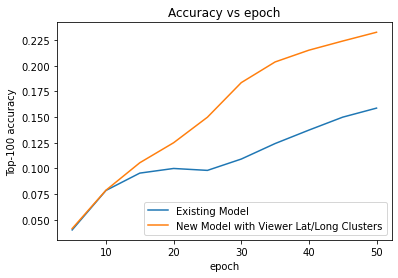

In [38]:
epochs = [(x + 1)* 5 for x in range(num_validation_runs)]

plt.plot(epochs, old_model_history.history["factorized_top_k/top_100_categorical_accuracy"], label="Existing Model")
plt.plot(epochs, new_model_history.history["factorized_top_k/top_100_categorical_accuracy"], label="New Model with Viewer Lat/Long Clusters")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

In [39]:
accuracy = old_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.1587.


In [40]:
accuracy = new_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.2326.


### Model summary

In [36]:
def full_summary(layer):

    #check if this layer has layers
    if hasattr(layer, 'layers'):
        print('summary for ' + layer.name)
        layer.summary()
        print('\n\n')

        for l in layer.layers:
            full_summary(l)

In [37]:
full_summary(model.broadcaster_model)
full_summary(model.embedding_model)

summary for broadcaster_model_1
Model: "broadcaster_model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_15 (Sequential)   (None, 32)                151136    
Total params: 151,136
Trainable params: 151,136
Non-trainable params: 0
_________________________________________________________________



summary for sequential_15
Model: "sequential_15"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
string_lookup_11 (StringLook (None,)                   0         
_________________________________________________________________
embedding_15 (Embedding)     (None, 32)                151136    
Total params: 151,136
Trainable params: 151,136
Non-trainable params: 0
_________________________________________________________________



summary for user_model_1
Model: "user_model_1"
_________________________________

In [38]:
model.broadcaster_model.summary()

Model: "broadcaster_model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_15 (Sequential)   (None, 32)                151136    
Total params: 151,136
Trainable params: 151,136
Non-trainable params: 0
_________________________________________________________________


In [39]:
model.embedding_model.summary()

Model: "user_model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_7 (Sequential)    (None, 2)                 6         
_________________________________________________________________
sequential_8 (Sequential)    (None, 8)                 184       
_________________________________________________________________
sequential_9 (Sequential)    (None, 10)                600       
_________________________________________________________________
sequential_10 (Sequential)   (None, 4)                 20        
_________________________________________________________________
sequential_11 (Sequential)   (None, 2)                 34        
_________________________________________________________________
sequential_12 (Sequential)   (None, 2)                 18        
_________________________________________________________________
sequential_13 (Sequential)   (None, 2)                

In [53]:
import datetime, os
logdir = 'logs/fit'
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir)

num_epochs = 10

model = TwoTowers(broadcaster_model, user_model, task)
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(
        learning_rate=learning_rate))

model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=1,
    callbacks=[tensorboard_callback]
)

accuracy = model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.2f}.")

Epoch 1/10
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2021-11-04 14:25:50.435871: I tensorflow/core/profiler/lib/profiler_session.cc:126] Profiler session initializing.
2021-11-04 14:25:50.435896: I tensorflow/core/profiler/lib/profiler_session.cc:141] Profiler session started.
2021-11-04 14:25:50.436819: I tensorflow/core/profiler/lib/profiler_session.cc:159] Profiler session tear down.


Consider rewriting this model with the Functional API.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow

2021-11-04 14:25:52.017465: I tensorflow/core/profiler/lib/profiler_session.cc:126] Profiler session initializing.
2021-11-04 14:25:52.017481: I tensorflow/core/profiler/lib/profiler_session.cc:141] Profiler session started.


2/3 [===================>..........] - ETA: 0s - factorized_top_k/top_1_categorical_accuracy: 0.0122 - factorized_top_k/top_5_categorical_accuracy: 0.1851 - factorized_top_k/top_10_categorical_accuracy: 0.2947 - factorized_top_k/top_50_categorical_accuracy: 0.5938 - factorized_top_k/top_100_categorical_accuracy: 0.7439 - loss: 8721.4043 - regularization_loss: 0.0000e+00 - total_loss: 8721.4043

2021-11-04 14:25:52.324951: I tensorflow/core/profiler/lib/profiler_session.cc:66] Profiler session collecting data.
2021-11-04 14:25:52.364539: I tensorflow/core/profiler/lib/profiler_session.cc:159] Profiler session tear down.
2021-11-04 14:25:52.397000: I tensorflow/core/profiler/rpc/client/save_profile.cc:137] Creating directory: logs/fit/train/plugins/profile/2021_11_04_14_25_52
2021-11-04 14:25:52.415311: I tensorflow/core/profiler/rpc/client/save_profile.cc:143] Dumped gzipped tool data for trace.json.gz to logs/fit/train/plugins/profile/2021_11_04_14_25_52/lhuang-laptop.local.trace.json.gz
2021-11-04 14:25:52.430235: I tensorflow/core/profiler/rpc/client/save_profile.cc:137] Creating directory: logs/fit/train/plugins/profile/2021_11_04_14_25_52
2021-11-04 14:25:52.430446: I tensorflow/core/profiler/rpc/client/save_profile.cc:143] Dumped gzipped tool data for memory_profile.json.gz to logs/fit/train/plugins/profile/2021_11_04_14_25_52/lhuang-laptop.local.memory_profile.json.gz
2

3/3 [==============================] - 2s 324ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0122 - factorized_top_k/top_5_categorical_accuracy: 0.1729 - factorized_top_k/top_10_categorical_accuracy: 0.2742 - factorized_top_k/top_50_categorical_accuracy: 0.5651 - factorized_top_k/top_100_categorical_accuracy: 0.7158 - loss: 7536.7930 - regularization_loss: 0.0000e+00 - total_loss: 7536.7930
Epoch 2/10
3/3 [==============================] - 1s 211ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0360 - factorized_top_k/top_5_categorical_accuracy: 0.2135 - factorized_top_k/top_10_categorical_accuracy: 0.3101 - factorized_top_k/top_50_categorical_accuracy: 0.6084 - factorized_top_k/top_100_categorical_accuracy: 0.7567 - loss: 7240.9707 - regularization_loss: 0.0000e+00 - total_loss: 7240.9707
Epoch 3/10
3/3 [==============================] - 1s 228ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0584 - factorized_top_k/top_5_categorical_accuracy: 0.2528 - factorize

In [50]:
!kill 12373

In [54]:
# %load_ext tensorboard
%reload_ext tensorboard

%tensorboard --logdir logs/fit

Reusing TensorBoard on port 6007 (pid 12425), started 0:01:44 ago. (Use '!kill 12425' to kill it.)

In [42]:
print(model.broadcaster_model.layers[0].get_weights()[1][1:100])

[4719 4716 4715 4713 4711 4709 4707 4705 4703 4702 4701 4698 4697 4696
 4692 4691 4689 4687 4686 4685 4684 4680 4677 4675 4669 4665 4663 4661
 4659 4658 4649 4646 4645 4641 4640 4638 4635 4634 4633 4632 4631 4630
 4629 4627 4626 4622 4619 4618 4613 4612 4608 4607 4606 4700 4605 4604
 4599 4590 4589 4586 4585 4581 4577 4683 4575 4572 4569 4568 4567 4566
 4564 4562 4558 4557 4556 4554 4551 4549 4547 4541 4540 4538 4537 4536
 4534 4533 4532 4530 4529 4525 4521 4520 4513 4512 4510 4504 4502 4501
 4500]


In [45]:
broadcaster_list = []
for i in train.map(lambda x: x["broadcaster"]):
    broadcaster_list.append(i.numpy().decode("utf-8"))

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [60]:
from tensorboard.plugins import projector
import shutil

In [64]:
logdir = 'meta-logs/projectors/'
if not os.path.exists(logdir):
    os.makedirs(logdir)
else:
    shutil.rmtree(logdir)
    os.makedirs(logdir)

with open(os.path.join(logdir, 'metadata.tsv'), "w") as f:
    for i in broadcaster_list[1:]:
        f.write(i+"\n")

In [66]:
weights = tf.Variable(model.broadcaster_model.layers[0].get_weights()[0][1:])
# Create a checkpoint from embedding, the filename and key are
# name of the tensor.
checkpoint = tf.train.Checkpoint(embedding=weights)
checkpoint.save(os.path.join(logdir, "embedding.ckpt"))

# Set up config
config = projector.ProjectorConfig()
embedding = config.embeddings.add()
# The name of the tensor will be suffixed by `/.ATTRIBUTES/VARIABLE_VALUE`
embedding.tensor_name = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
embedding.metadata_path = 'metadata.tsv'
projector.visualize_embeddings(logdir, config)